# SEC XBRL Fundamentals

**Chapter 4: Fundamental and Alternative Data**
**Docker image**: `ml4t`

**Section Reference**: Section 4.1 (The Point-in-Time Pipeline)

## Purpose

A fundamental value has two dates. There is the period it describes, and there is the day the
filing carrying it reached the SEC. Between the two, nobody in the market knew the number. A
backtest that keys a fundamental to its period end is therefore trading on information it did
not have, and the error is invisible in the results: the strategy simply looks better than it
was.

This notebook reads the quarterly panel that `data/equities/fundamentals/xbrl_download.py`
assembles from the SEC's XBRL Frames API, measures how far apart those two dates actually
are, and builds the query that respects the gap. Chapter 8 turns the panel into features.

## Learning Objectives

After completing this notebook, you will be able to:

- Read a quarterly fundamentals panel that carries both the period a value describes and the
  date the filing reporting it was submitted.
- Measure how completely each reported concept covers the companies and quarters in a panel,
  and say why a concept is missing where it is.
- Measure the delay between a fiscal quarter's end and the filing that reports it, and
  recognize the two populations that delay is drawn from.
- Write an as-of query that returns only what was public on a given date, filtering on the
  filing date and ranking on the period.
- Show what the same query returns when it filters on the period instead, and count the
  companies for which the two answers differ.

## Why Direct API vs edgartools?

The `02_sec_filing_explorer.py` notebook demonstrates using the edgartools library for
**individual company analysis**: exploring filings, extracting financial statements,
and parsing 13F holdings. edgartools is excellent for deep dives into specific companies.

This notebook takes a different approach: **bulk data retrieval** using the SEC's
XBRL Frames API, which provides aggregated data across all filers in a single request.
This is more efficient for building cross-sectional fundamental datasets.

| Use Case | Best Tool |
|----------|-----------|
| Analyze a single company's filings | `02_sec_filing_explorer.py` |
| Build factor dataset for 20+ stocks | This notebook (XBRL Frames API) |
| Parse complex filing documents | `02_sec_filing_explorer.py` |
| Get quarterly aggregates across market | This notebook (XBRL Frames API) |

## Point-in-Time (PIT) Correctness

**Critical**: Fundamental data for backtesting must reflect only information
available at each historical date. Using fiscal quarter end dates causes
look-ahead bias because filings are released 30-60 days later.

The downloader joins **filing dates** from the SEC Submissions API onto the
XBRL frames so each row carries both `fiscal_quarter_end` (valid time) and
`announcement_date` (knowledge time):

| Date Type | Usage |
|-----------|-------|
| `fiscal_quarter_end` | Period the data describes (e.g., 2024-03-31) |
| `announcement_date` | When SEC filing was submitted (e.g., 2024-05-02) |

For backtesting, use `announcement_date` as the point when data becomes available.

## Data Sources

The downloader uses two free, public SEC EDGAR APIs (no vendor subscription):

1. **XBRL Frames API** — aggregated financial data across all filers:
   `https://data.sec.gov/api/xbrl/frames/{taxonomy}/{concept}/{unit}/{period}.json`

   **CY vs FY Frames**: The API uses **CY** (calendar year) quarters, not fiscal year.
   This is intentional: CY frames provide cross-sectional snapshots where all companies
   report the same calendar period, enabling apples-to-apples comparisons.
   Companies with non-calendar fiscal years (e.g., MSFT ends June 30) have their
   data mapped to the appropriate CY quarter.

2. **Submissions API** — per-company filing metadata cached per CIK on first
   fetch so re-runs do not re-hit the endpoint:
   `https://data.sec.gov/submissions/CIK{cik}.json`

## Downloader

```bash
# 20 large-cap US equities × 2022-2024 × 11 standard concepts (~2-3 min)
uv run python data/equities/fundamentals/xbrl_download.py

# Custom year range or CIK list
uv run python data/equities/fundamentals/xbrl_download.py --years 2020,2021,2022,2023,2024
uv run python data/equities/fundamentals/xbrl_download.py --ciks 320193
```

The loader raises `DataNotFoundError` with the exact command if the parquet
is missing — no hidden HTTP calls inside the notebook.

## Cross-References

- **Related**: [`02_sec_filing_explorer`](02_sec_filing_explorer.ipynb) (individual company SEC filings)
- **Downstream**: `08_financial_features/04_fundamentals_macro_calendar.py` (factor engineering)

In [1]:
"""SEC XBRL Fundamentals — analyze quarterly fundamentals from the canonical xbrl_download.py output."""

import plotly.graph_objects as go
import polars as pl

from data import load_sec_xbrl_fundamentals

# Importing utils.style registers and activates the ML4T Plotly template
from utils.style import COLORS

The as-of demonstration in Part 4 needs a date to be run for. Any date inside the panel's
range works. One falling shortly after a quarter end shows the widest gap between a query
that respects the filing date and one that does not, because that is the moment when the most
recent quarter has ended and has not yet been reported.

In [2]:
AS_OF_DATE = "2023-06-30"  # the simulated date the Part 4 queries are run for

## 1. Load the fundamentals panel

The downloader ships a default universe of twenty large-cap US equities with eleven standard
us-gaap concepts. Each row is one company and one fiscal quarter, and carries the period end,
the filing date, the accession number of the filing it came from, and the concepts that
company reported for that period.

In [3]:
fundamentals = load_sec_xbrl_fundamentals()

print(f"Rows:                 {len(fundamentals):,}")
print(f"Companies:            {fundamentals['cik'].n_unique()}")
print(f"Distinct period ends: {fundamentals['fiscal_quarter_end'].n_unique()}")
print(f"Earliest period end:  {fundamentals['fiscal_quarter_end'].min()}")
print(f"Latest period end:    {fundamentals['fiscal_quarter_end'].max()}")
print(f"Columns:              {fundamentals.columns}")

Rows:                 240
Companies:            20
Distinct period ends: 49
Earliest period end:  2022-03-26
Latest period end:    2025-01-26
Columns:              ['symbol', 'cik', 'entity_name', 'fiscal_quarter_end', 'announcement_date', 'accession', 'assets', 'cashandcashequivalentsatcarryingvalue', 'grossprofit', 'liabilities', 'longtermdebt', 'netcashprovidedbyusedinoperatingactivities', 'netincomeloss', 'operatingincomeloss', 'paymentstoacquirepropertyplantandequipment', 'revenues', 'stockholdersequity']


### What the panel holds

Two views of the same rows, one for the balance sheet and one for the income and cash-flow
concepts, are enough to see the shape. `announcement_date` sits beside `fiscal_quarter_end`
in both, because every question in the rest of this notebook is about the distance between
them.

In [4]:
balance_cols = [
    c
    for c in [
        "symbol",
        "entity_name",
        "fiscal_quarter_end",
        "announcement_date",
        "assets",
        "liabilities",
        "stockholdersequity",
    ]
    if c in fundamentals.columns
]
fundamentals.select(balance_cols).head(8)

symbol,entity_name,fiscal_quarter_end,announcement_date,assets,liabilities,stockholdersequity
str,str,date,date,i64,i64,i64
"""AAPL""","""Apple Inc.""",2022-03-26,2022-04-29,350662000000,283263000000,67399000000
"""AAPL""","""Apple Inc.""",2022-06-25,2022-07-29,336309000000,278202000000,58107000000
"""AAPL""","""Apple Inc.""",2022-09-24,2023-11-03,352755000000,302083000000,50672000000
"""AAPL""","""Apple Inc.""",2022-12-31,2023-02-03,346747000000,290020000000,56727000000
"""AAPL""","""Apple Inc.""",2023-04-01,2023-05-05,332160000000,270002000000,62158000000
"""AAPL""","""Apple Inc.""",2023-07-01,2023-08-04,335038000000,274764000000,60274000000
"""AAPL""","""Apple Inc.""",2023-09-30,2024-11-01,352583000000,290437000000,62146000000
"""AAPL""","""Apple Inc.""",2023-12-30,2024-02-02,353514000000,279414000000,74100000000


`revenues` is sparse, and the reason is a taxonomy change rather than a gap in the data.
Accounting Standards Codification Topic 606, effective for most filers from 2018, replaced
the general revenue concept with one that names the source of the revenue, and large filers
now tag their top line as `RevenueFromContractWithCustomerExcludingAssessedTax`. The
downloader keeps that in its own column rather than folding it into `revenues`, so a null
here means "reported under a different concept", not "did not report".

In [5]:
flow_cols = [
    c
    for c in [
        "symbol",
        "fiscal_quarter_end",
        "announcement_date",
        "revenues",
        "netincomeloss",
        "netcashprovidedbyusedinoperatingactivities",
    ]
    if c in fundamentals.columns
]
fundamentals.select(flow_cols).head(8)

symbol,fiscal_quarter_end,announcement_date,revenues,netincomeloss,netcashprovidedbyusedinoperatingactivities
str,date,date,i64,i64,i64
"""AAPL""",2022-03-26,2022-04-29,null,25010000000,null
"""AAPL""",2022-06-25,2022-07-29,null,19442000000,null
"""AAPL""",2022-09-24,2023-11-03,null,null,null
"""AAPL""",2022-12-31,2023-02-03,null,29998000000,34005000000
"""AAPL""",2023-04-01,2023-05-05,null,24160000000,null
"""AAPL""",2023-07-01,2023-08-04,null,19881000000,null
"""AAPL""",2023-09-30,2024-11-01,null,null,null
"""AAPL""",2023-12-30,2024-02-02,null,33916000000,39895000000


## 2. Coverage

Before anything is computed from a panel, it is worth knowing which cells of it are actually
filled. A concept missing for one company in one quarter is a null a feature will have to
handle; a concept missing for a whole industry is a signal that the industry tags it
differently, and no amount of imputation will recover it. The grid below counts the rows
carrying `assets` for each company and calendar quarter.

In [6]:
coverage_df = (
    fundamentals.with_columns(
        (
            pl.col("fiscal_quarter_end").dt.year().cast(pl.Utf8)
            + "Q"
            + ((pl.col("fiscal_quarter_end").dt.month() - 1) // 3 + 1).cast(pl.Utf8)
        ).alias("quarter")
    )
    .group_by(["symbol", "quarter"])
    .agg(
        pl.col("assets").is_not_null().sum().alias("assets_available"),
    )
)

coverage_pivot = coverage_df.pivot(
    on="quarter", index="symbol", values="assets_available"
).fill_null(0)

quarters = sorted(c for c in coverage_pivot.columns if c != "symbol")
coverage_pivot = coverage_pivot.sort("symbol")
symbols = coverage_pivot["symbol"].to_list()
matrix = coverage_pivot.select(quarters).to_numpy().astype(int)

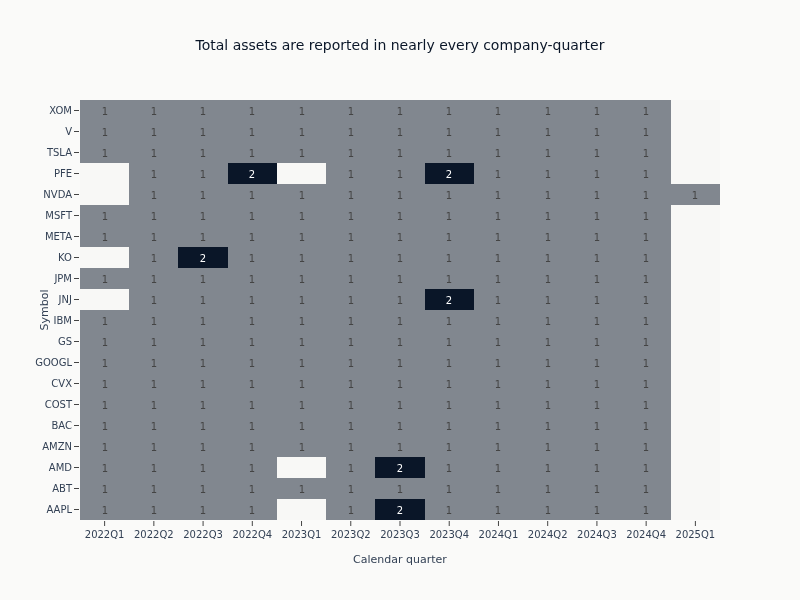

Company-quarter cells: 260
Cells reporting total assets: 234 (90.0%)


In [7]:
fig = go.Figure(
    data=go.Heatmap(
        z=matrix,
        x=quarters,
        y=symbols,
        colorscale=[[0, COLORS["silver"]], [1, COLORS["blue"]]],
        showscale=False,
        text=[[str(v) if v > 0 else "" for v in row] for row in matrix.tolist()],
        texttemplate="%{text}",
        textfont={"size": 10},
    )
)
fig.update_layout(
    title="Total assets are reported in nearly every company-quarter",
    xaxis_title="Calendar quarter",
    yaxis_title="Symbol",
    height=600,
    width=800,
)
fig.show()

# A cell counts once however many rows sit in it. Some hold two - an original filing and an
# amendment that maps to the same calendar quarter, which is where a "2" in the grid comes
# from - and summing the counts would read a restatement as extra coverage.
total_cells = matrix.size
filled_cells = int((matrix > 0).sum())
print(f"Company-quarter cells: {total_cells}")
print(f"Cells reporting total assets: {filled_cells} ({filled_cells / total_cells:.1%})")

## 3. How long the market waits

The gap between the period end and the filing date is the window during which the quarter has
happened and nobody outside the company knows its numbers. Its size is what decides how far a
fundamental has to be lagged before a backtest may use it, and its shape is what decides
whether a single lag is adequate at all.

In [8]:
filing_lag = (
    fundamentals.filter(pl.col("announcement_date").is_not_null())
    .with_columns(
        (pl.col("announcement_date") - pl.col("fiscal_quarter_end"))
        .dt.total_days()
        .alias("lag_days")
    )
    .select(["symbol", "fiscal_quarter_end", "lag_days"])
)

filing_lag.select("lag_days").describe()

statistic,lag_days
str,f64
"""count""",204.0
"""null_count""",0.0
"""mean""",149.191176
"""std""",192.045607
"""min""",19.0
"""25%""",27.0
"""50%""",33.0
"""75%""",395.0
"""max""",781.0


The median is the routine case: a 10-Q is due within forty days of quarter end for a large
filer, and most land close to that. The mean sits far above the median, which is the
signature of a second population rather than a wide first one. That population is
restatements and late-attributed facts: the Frames API returns the accession number of the
filing where a fact appears, and a fact restated in a later document is dated to the later
document. Treating that as knowledge time is conservative, in the sense that it makes the
number available later than it really was, which is the direction a backtest can survive.

A distribution with two populations is exactly the case a single summary statistic hides,
so the histogram is what settles it.

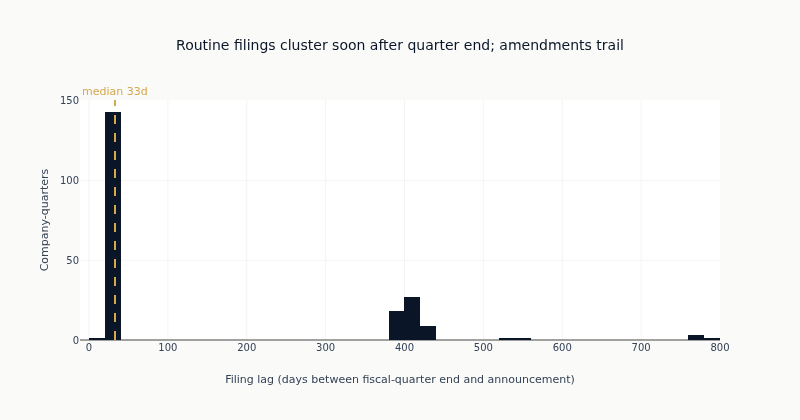

In [9]:
lags = filing_lag["lag_days"].to_list()
median_lag = filing_lag["lag_days"].median()

fig = go.Figure(
    data=go.Histogram(
        x=lags,
        xbins={"start": 0, "end": 800, "size": 20},
        marker_color=COLORS["blue"],
    )
)
fig.add_vline(
    x=median_lag,
    line_dash="dash",
    line_color=COLORS["amber"],
    annotation_text=f"median {median_lag:.0f}d",
    annotation_position="top",
    annotation_font_color=COLORS["amber"],
)
fig.update_layout(
    title="Routine filings cluster soon after quarter end; amendments trail",
    xaxis_title="Filing lag (days between fiscal-quarter end and announcement)",
    yaxis_title="Company-quarters",
    height=420,
    width=800,
)
fig.show()

## 4. Querying two time dimensions at once

A panel carrying both dates is **bitemporal**: each row has a *valid time*, the period the
fact describes, and a *knowledge time*, the date the fact became public. Here they are
`fiscal_quarter_end` and `announcement_date`.

The two decide different things, and the whole correctness of an as-of query is in keeping
them apart. Knowledge time decides **admissibility**: a row may be used only if the market
already knew it on the date being simulated. Valid time decides **recency**: among the rows
that pass, the one describing the most recent period is the one to carry forward.

Conflating them fails in both directions. Filtering on valid time admits quarters that had
ended but had not been filed, which is the classic lookahead. Sorting on knowledge time
returns the most recently *announced* row rather than the most recent *quarter*, so a
restatement or a late-attributed fact walks the answer backwards in fiscal time - and the
long tail measured in Part 3 says that is a normal event in this panel rather than an edge
case. Filter on `announcement_date`; rank on `fiscal_quarter_end`.

In [10]:
def query_fundamentals_as_of(df: pl.DataFrame, as_of_date: str) -> pl.DataFrame:
    """Return latest known fundamentals as of a specific date (PIT-correct).

    Admissibility is set by `announcement_date` (what the market knew); recency is set
    by `fiscal_quarter_end` (which period the fact describes).
    """
    query_date = pl.lit(as_of_date).str.to_date()
    return (
        df.filter(pl.col("announcement_date") <= query_date)
        # Two rows can describe the same quarter - an original filing and a later
        # restatement of it. Ordering on the filing date within the quarter makes the
        # restatement win, and makes the choice deterministic rather than incidental.
        .sort(["symbol", "fiscal_quarter_end", "announcement_date"])
        .group_by("symbol", maintain_order=True)
        .last()
    )

A row with no `announcement_date` has no knowledge time, so it can never be shown to
be admissible and the filter drops it. That is the right call, but a silent one: the
coverage it costs is worth stating out loud before relying on the panel.

In [11]:
n_null = fundamentals["announcement_date"].is_null().sum()
print(f"Rows with no announcement_date: {n_null} of {fundamentals.height}")
print(f"Share of the panel never admissible to an as-of query: {n_null / fundamentals.height:.1%}")

Rows with no announcement_date: 36 of 240
Share of the panel never admissible to an as-of query: 15.0%


### Demonstration: Correct vs Incorrect Queries

Both queries below run on the rows that carry a knowledge time. Restricting the
comparison to a single universe is what makes it a clean read on lookahead bias: if
the correct query dropped the null-`announcement_date` rows and the lookahead one kept
them, the mismatch count would mix the coverage gap into the answer.

In [12]:
pit_panel = fundamentals.filter(pl.col("announcement_date").is_not_null())
print(f"As of {AS_OF_DATE}, the latest quarter known to the market for each symbol:")

As of 2023-06-30, the latest quarter known to the market for each symbol:


**Correct** — filter on `announcement_date <= as_of`:

In [13]:
known_correct = query_fundamentals_as_of(pit_panel, AS_OF_DATE)
cols = [
    c
    for c in ["symbol", "fiscal_quarter_end", "announcement_date", "netincomeloss"]
    if c in known_correct.columns
]
known_correct.select(cols).head(5)

symbol,fiscal_quarter_end,announcement_date,netincomeloss
str,date,date,i64
"""AAPL""",2023-04-01,2023-05-05,24160000000
"""ABT""",2023-03-31,2023-05-04,1318000000
"""AMD""",2023-04-01,2023-05-03,-139000000
"""AMZN""",2023-03-31,2023-04-28,3172000000
"""COST""",2023-03-31,2023-05-01,4228000000


**Lookahead-biased** — filter on `fiscal_quarter_end <= as_of`. This includes
quarters whose filings hadn't been submitted yet on the as-of date:

In [14]:
query_date = pl.lit(AS_OF_DATE).str.to_date()
known_wrong = (
    pit_panel.filter(pl.col("fiscal_quarter_end") <= query_date)
    .sort(["symbol", "fiscal_quarter_end", "announcement_date"])
    .group_by("symbol", maintain_order=True)
    .last()
)
known_wrong.select(cols).head(5)

symbol,fiscal_quarter_end,announcement_date,netincomeloss
str,date,date,i64
"""AAPL""",2023-04-01,2023-05-05,24160000000
"""ABT""",2023-06-30,2023-08-03,1375000000
"""AMD""",2023-04-01,2023-05-03,-139000000
"""AMZN""",2023-06-30,2023-08-04,6750000000
"""COST""",2023-06-30,2023-07-27,4489000000


Comparing the two — every row here is a symbol the lookahead-biased approach
would have used a fresher quarter than was actually available:

In [15]:
correct_dates = known_correct.select(["symbol", "fiscal_quarter_end"]).rename(
    {"fiscal_quarter_end": "correct_qtr"}
)
wrong_dates = known_wrong.select(["symbol", "fiscal_quarter_end"]).rename(
    {"fiscal_quarter_end": "wrong_qtr"}
)
mismatches = correct_dates.join(wrong_dates, on="symbol").filter(
    pl.col("correct_qtr") != pl.col("wrong_qtr")
)
print(f"{len(mismatches)} symbols where lookahead bias would change the chosen quarter:")
mismatches

11 symbols where lookahead bias would change the chosen quarter:


symbol,correct_qtr,wrong_qtr
str,date,date
"""ABT""",2023-03-31,2023-06-30
"""AMZN""",2023-03-31,2023-06-30
"""COST""",2023-03-31,2023-06-30
"""CVX""",2023-03-31,2023-06-30
"""GOOGL""",2023-03-31,2023-06-30
…,…,…
"""KO""",2023-03-31,2023-06-30
"""MSFT""",2023-03-31,2023-06-30
"""TSLA""",2023-03-31,2023-06-30


## Key Takeaways

1. The SEC's XBRL Frames API is enough to assemble a cross-sectional fundamentals panel with
   no vendor subscription. What it costs is that the panel arrives in the SEC's terms rather
   than a vendor's: calendar quarters, us-gaap concept names, and one row per fact as filed.
2. A missing concept is usually a tagging difference rather than an absent disclosure.
   `revenues` is null for filers who tag their top line under the post-ASC-606 concept, so
   measure coverage per concept before treating a null as a gap, and read the pattern of the
   nulls before imputing anything.
3. The delay between a quarter ending and its filing arriving is drawn from two populations,
   not one. Routine reports land inside the statutory window; restatements and facts
   attributed to a later document arrive much later, and a mean computed over both describes
   neither. Look at the distribution, not the average.
4. An as-of query filters on knowledge time and ranks on valid time. Filtering on valid time
   admits quarters that had not been filed yet, which is lookahead. Ranking on knowledge time
   returns the most recently announced row rather than the most recent quarter, so it walks
   backwards in fiscal time every time a restatement lands. The comparison above counts the
   companies for which the two answers differ on one date.
5. Knowledge time can be missing. A row with no filing date can never be shown to have been
   public, so an as-of query drops it - silently, unless the panel says how many rows that is.
   Report the gap rather than discovering it later as unexplained coverage loss.
6. The downloader and the loader are the production interface. This notebook is the check
   that the panel is sound and the template for querying it; the feature engineering happens
   in `08_financial_features/04_fundamentals_macro_calendar.py`.